# Lab 2 — Digital Modulation and Optimal Detection

**Companion to Chapter 9** (*Digital Modulation and Optimal Detection*).
**Time needed:** about 75 minutes. **Difficulty:** core.

A modulator maps bits to points in a signal space; a detector draws the best possible
boundaries between those points. In this lab you will build the constellations used by
every modern standard, prove to yourself that "pick the nearest point" is optimal in
Gaussian noise, measure error rates against the closed forms of Chapter 9, and then
step outside the linear world to FSK, DPSK and the constant-envelope MSK/GMSK family.

### What you will learn
1. Build PSK, QAM and APSK constellations with unit average energy and read off $d_{\min}$ and PAPR.
2. See that the ML detector in AWGN is minimum distance (Voronoi decision regions).
3. Measure SER/BER by Monte Carlo and match the closed forms and the union bound.
4. Quantify the value of Gray labelling and compute soft bit LLRs for decoders.
5. Compare coherent and noncoherent detection (FSK, DPSK) and the spectra of MSK and GMSK.

### Prerequisites
Lab 1 (complex baseband). The $Q$-function and Gaussian noise (Chapter 3).

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | A constellation gallery | |
| 2 | Signal space: from waveforms to points | |
| 3 | Decision regions of the ML detector | |
| 4 | Monte Carlo BER versus theory | yes |
| 5 | Gray labelling | |
| 6 | The union bound | |
| 7 | Orthogonal FSK and DPSK: noncoherent detection | |
| 8 | Constant envelope: MSK and GMSK | yes |
| 9 | Soft information: bit LLRs | |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
import commlib as cl
from commlib import labkit as lk

rng = lk.setup(seed=2, lab="02")

Lab 02 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 2


## 1. A constellation gallery

Every constellation in the course is scaled to unit average energy, $E_s = E[|a|^2] = 1$,
so $E_s/N_0$ in dB is simply the SNR per symbol. Two numbers summarise a constellation:

* the **minimum distance** $d_{\min}$, which sets the error rate at high SNR, and
* the **peak-to-average power ratio** $\max|a|^2 / E|a|^2$, which sets how far the
  power amplifier must back off.

The last panel is **16-APSK** (4 + 12 rings) from DVB-S2: it gives up a little $d_{\min}$
relative to 16-QAM for a lower PAPR, a good trade on a saturated satellite amplifier (Lab 18).

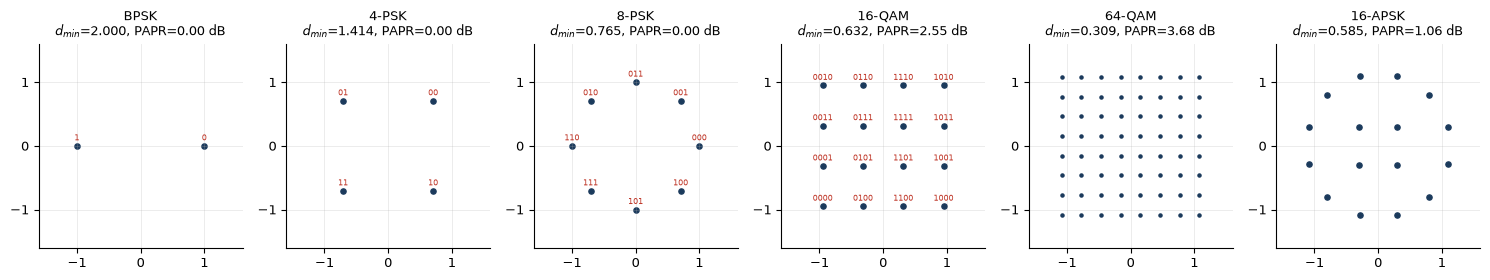

In [3]:
def apsk16(ratio=2.7):
    inner = np.exp(1j * (np.pi / 4 + np.pi / 2 * np.arange(4)))
    outer = ratio * np.exp(1j * (np.pi / 12 + np.pi / 6 * np.arange(12)))
    return cl.Constellation(np.concatenate([inner, outer]), np.arange(16), "16-APSK")

consts = [cl.get_constellation(n) for n in ["bpsk", "qpsk", "8psk", "16qam", "64qam"]] + [apsk16()]
f, axes = lk.fig((15, 2.9), 1, 6)
for ax, c in zip(axes, consts):
    ax.scatter(c.points.real, c.points.imag, s=14 if c.M < 64 else 5, color=lk.NAVY)
    if c.M <= 16 and c.name != "16-APSK":
        for p, lab in zip(c.points, c.labels):
            ax.annotate(format(lab, f"0{c.k}b"), (p.real, p.imag), fontsize=6, color=lk.RED,
                        textcoords="offset points", xytext=(0, 4), ha="center")
    papr = lk.db(np.max(np.abs(c.points) ** 2))
    ax.set_title(f"{c.name}\n$d_{{min}}$={c.dmin:.3f}, PAPR={papr:.2f} dB", fontsize=9)
    ax.set_aspect("equal"); ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
    ax.set_xticks([-1, 0, 1]); ax.set_yticks([-1, 0, 1])
lk.show(f)

**What you should see.** PSK points all sit on the unit circle (PAPR 0 dB); QAM trades
PAPR for a larger $d_{\min}$ at the same $M$. The labels next to 4/8/16-point
constellations are **Gray** labels: neighbours differ in exactly one bit.

### Try it yourself 1.1
For unit-energy square $M$-QAM, $d_{\min} = \sqrt{6/(M-1)}$. Compute it for 256-QAM.

In [5]:
answer_1_1 = None
lk.check("1.1 d_min of 256-QAM", answer_1_1, cl.get_constellation("256qam").dmin, rtol=0.01)

[TODO] 1.1 d_min of 256-QAM: not attempted yet: replace the None with your answer

## 2. Signal space: from waveforms to points

A QPSK waveform is $s(t) = a_I\,\phi_1(t) + a_Q\,\phi_2(t)$ with orthonormal basis
functions $\phi_1 = \sqrt{2/T}\cos(2\pi f_c t)$ and $\phi_2 = -\sqrt{2/T}\sin(2\pi f_c t)$.
A receiver that correlates the noisy waveform against each basis function,
$r_i = \int r(t)\phi_i(t)\,dt$, loses *nothing*: the noise components outside the span
of the basis are irrelevant to the decision (the **theorem of irrelevance**). The
correlator outputs are exactly the constellation points plus independent Gaussian noise
of variance $N_0/2$ per dimension.

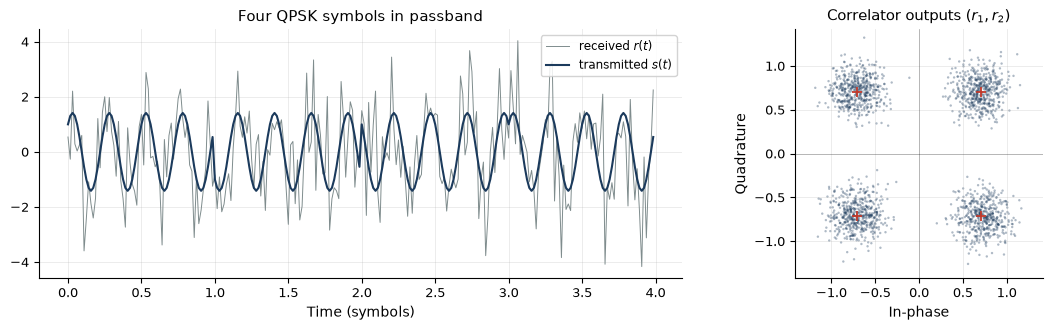

Measured noise variance per dimension: 0.0259   (theory N0/2 = 0.0250)


In [7]:
T, fc_, ns = 1.0, 4.0, 64                               # symbol time, carrier cycles/T, samples/T
tt = np.arange(ns) / ns * T
phi1 = np.sqrt(2 / T) * np.cos(2 * np.pi * fc_ * tt)
phi2 = -np.sqrt(2 / T) * np.sin(2 * np.pi * fc_ * tt)
qpsk = cl.get_constellation("qpsk")
a = qpsk.modulate(cl.random_bits(2 * 2000, rng))
wave = a.real[:, None] * phi1 + a.imag[:, None] * phi2   # (symbols, samples) passband waveforms
n0 = 0.05
r = wave + np.sqrt(n0 / 2 * ns / T) * rng.standard_normal(wave.shape)   # white noise, PSD N0/2
dt = T / ns
ri = (r @ phi1) * dt + 1j * (r @ phi2) * dt                              # correlator bank

f, ax = lk.fig((11, 3.4), 1, 2, gridspec_kw={"width_ratios": [2, 1]})
ax[0].plot(np.arange(4 * ns) / ns, r[:4].ravel(), color=lk.GRAY, lw=0.7, label="received $r(t)$")
ax[0].plot(np.arange(4 * ns) / ns, wave[:4].ravel(), color=lk.NAVY, label="transmitted $s(t)$")
ax[0].set_xlabel("Time (symbols)"); ax[0].legend(loc="upper right"); ax[0].set_title("Four QPSK symbols in passband")
lk.constellation(ax[1], ri, qpsk.points, "Correlator outputs $(r_1, r_2)$")
lk.show(f)
print(f"Measured noise variance per dimension: {np.var((ri - a).real):.4f}   (theory N0/2 = {n0 / 2:.4f})")

**What you should see.** A messy passband waveform turns into four clean clusters whose
spread matches $N_0/2$ per dimension. Everything after this point in the course works on
those points.

## 3. Decision regions of the ML detector

With equiprobable symbols and AWGN, the MAP rule $\arg\max_a p(r\mid a)$ becomes
$\arg\min_a |r - a|^2$: pick the nearest point. The decision regions are therefore
**Voronoi cells**. We colour a grid by the detected symbol.

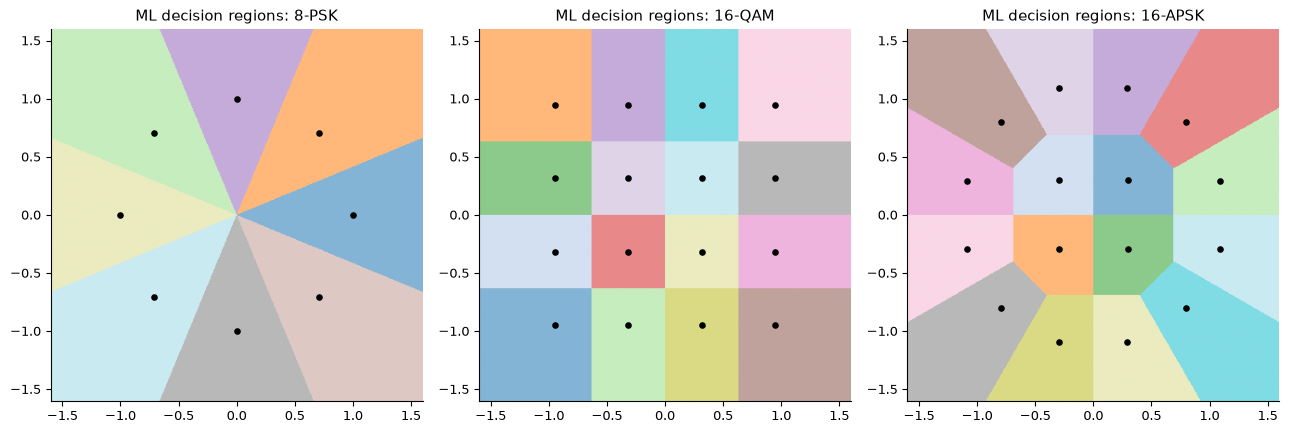

In [10]:
f, axes = lk.fig((13, 4.2), 1, 3)
for ax, c in zip(axes, [cl.get_constellation("8psk"), cl.get_constellation("16qam"), apsk16()]):
    g = np.linspace(-1.6, 1.6, 400)
    X, Y = np.meshgrid(g, g)
    idx = c.nearest((X + 1j * Y).ravel()).reshape(X.shape)
    ax.imshow(idx, extent=[-1.6, 1.6, -1.6, 1.6], origin="lower", cmap="tab20", alpha=0.55)
    ax.scatter(c.points.real, c.points.imag, c="k", s=14); ax.grid(False)
    ax.set_title(f"ML decision regions: {c.name}")
lk.show(f)

**What you should see.** Pie slices for PSK, a chessboard for QAM (so the detector
is two independent slicers, one for I and one for Q), and a ring-plus-sectors pattern
for APSK.

## 4. Monte Carlo BER versus theory

The course convention is $E_s/N_0 = E_b/N_0 + 10\log_{10}k$ for $k$ bits/symbol. Closed forms:

* BPSK/QPSK (Gray): $P_b = Q\big(\sqrt{2E_b/N_0}\big)$
* Square $M$-QAM (Gray, nearest neighbour):
  $P_b \approx \frac{4}{k}\left(1-\frac{1}{\sqrt M}\right) Q\!\left(\sqrt{\frac{3E_s}{(M-1)N_0}}\right)$
* $M$-PSK: $P_s \approx 2Q\big(\sqrt{2E_s/N_0}\sin(\pi/M)\big)$ and $P_b \approx P_s/k$ with Gray labels.

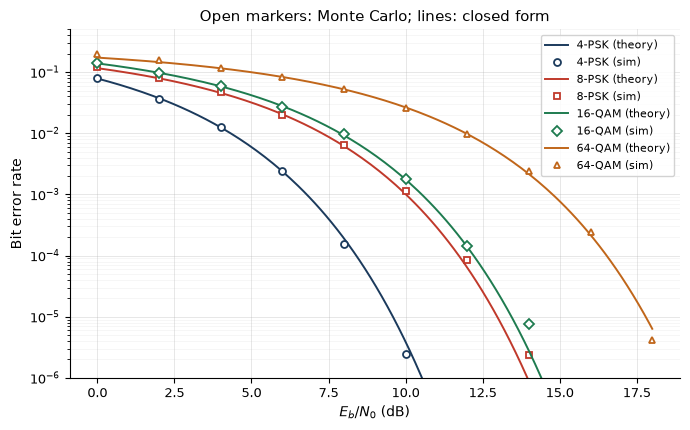

In [13]:
def mc_ber(c, ebn0_db, min_errors=200, max_bits=400_000):
    def trial(_):
        bits = cl.random_bits(c.k * 20_000, rng)
        y, _ = cl.awgn_esn0(c.modulate(bits), cl.ebn0_to_esn0(ebn0_db, c.k), rng=rng)
        return np.sum(c.demodulate(y) != bits), len(bits)
    return lk.ber_mc(trial, min_errors, max_bits)

def theory_ber(c, eb):
    es = cl.ebn0_to_esn0(eb, c.k)
    if c.M <= 4:
        return cl.ber_bpsk(eb)
    return cl.ser_mpsk(es, c.M) / c.k if "PSK" in c.name else cl.ber_mqam_gray(es, c.M)

eb = np.arange(0, 19, 2.0)
ebf = np.linspace(0, 18, 200)
sims, th = {}, {}
for nm in ["qpsk", "8psk", "16qam", "64qam"]:
    c = cl.get_constellation(nm)
    sims[c.name] = [mc_ber(c, e) for e in eb]
    th[c.name] = theory_ber(c, ebf)
f, ax = lk.fig("ber")
lk.ber_plot(ax, eb, sims, th, x_theory=ebf)
ax.set_title("Open markers: Monte Carlo; lines: closed form")
lk.show(f)

**What you should see.** Every marker sits on its line to within Monte Carlo noise. At
$10^{-5}$ QPSK needs about 9.6 dB, 16-QAM about 13.4 dB and 64-QAM about 17.8 dB: each
extra 2 bits/symbol costs roughly 4–5 dB of $E_b/N_0$.

### Interactive: constellation, noise and error rate
EVM (RMS error vector over RMS reference) is the metric used in 3GPP and 802.11
conformance tests; at high SNR, $\mathrm{EVM}_{\mathrm{dB}} \approx -E_s/N_0$.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

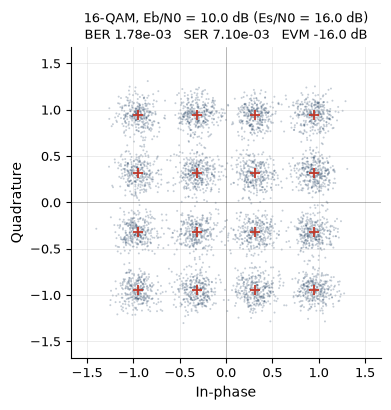

In [15]:
def explore(mod="16qam", ebn0_db=10.0):
    c = cl.get_constellation(mod)
    bits = cl.random_bits(c.k * 20_000, rng)
    s = c.modulate(bits)
    esn0 = cl.ebn0_to_esn0(ebn0_db, c.k)
    y, n0 = cl.awgn_esn0(s, esn0, rng=rng)
    ber = np.mean(c.demodulate(y) != bits)
    ser = np.mean(c.decide(y) != s)
    evm = lk.db(np.mean(np.abs(y - s) ** 2))
    f, ax = lk.fig("square")
    lk.constellation(ax, y, c.points, s=2, alpha=0.25)
    ax.set_title(f"{c.name}, Eb/N0 = {ebn0_db:.1f} dB (Es/N0 = {esn0:.1f} dB)\n"
                 f"BER {ber:.2e}   SER {ser:.2e}   EVM {evm:.1f} dB", fontsize=9)
    lk.show(f)

lk.interact(explore, mod=lk.choice(["bpsk", "qpsk", "8psk", "16psk", "16qam", "64qam", "256qam", "1024qam"],
                                   "16qam", "modulation"),
            ebn0_db=lk.slider(10, -2, 30, 0.5, "Eb/N0 (dB)"))

### Try it yourself 4.1
Using `cl.ber_bpsk` and a root finder (or trial and error), find the $E_b/N_0$ in dB at
which QPSK reaches $P_b = 10^{-6}$.

In [17]:
answer_4_1 = None
from scipy.optimize import brentq
lk.check("4.1 QPSK Eb/N0 for BER 1e-6", answer_4_1,
         brentq(lambda e: np.log10(cl.ber_bpsk(e)) + 6, 0, 20), atol=0.05)

[TODO] 4.1 QPSK Eb/N0 for BER 1e-6: not attempted yet: replace the None with your answer

## 5. Why Gray labelling matters

With Gray labels, adjacent points differ in one bit, so the most likely symbol error
costs one bit error. With natural binary labels it can cost several: at the same SER
the BER is higher.

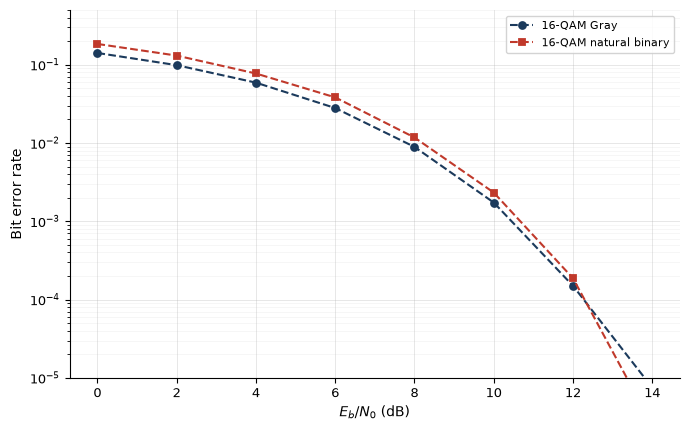

Eb/N0 (dB),BER Gray,BER natural,ratio
0,1.41e-01,1.84e-01,1.30
2,9.88e-02,1.31e-01,1.33
4,5.91e-02,7.73e-02,1.31
6,2.80e-02,3.83e-02,1.37
8,8.93e-03,1.18e-02,1.32
10,1.74e-03,2.33e-03,1.34
12,1.50e-04,1.88e-04,1.25
14,7.50e-06,2.50e-06,0.33


In [19]:
c_gray = cl.get_constellation("16qam")
lev = np.arange(-3, 4, 2)
I, Q = np.meshgrid(np.arange(4), np.arange(4), indexing="ij")
c_nat = cl.Constellation((lev[I] + 1j * lev[Q]).ravel(), (I * 4 + Q).ravel(), "16-QAM natural")
eb5 = np.arange(0, 15, 2.0)
b_gray = [mc_ber(c_gray, e) for e in eb5]
b_nat = [mc_ber(c_nat, e) for e in eb5]
f, ax = lk.fig("ber")
lk.ber_plot(ax, eb5, {"16-QAM Gray": b_gray, "16-QAM natural binary": b_nat})
ax.set_ylim(1e-5, 0.5)
lk.show(f)
lk.table([[e, bg, bn, bn / max(bg, 1e-12)] for e, bg, bn in zip(eb5, b_gray, b_nat)],
         ["Eb/N0 (dB)", "BER Gray", "BER natural", "ratio"], fmt={0: ".0f", 1: ".2e", 2: ".2e", 3: ".2f"})

**What you should see.** Natural binary labelling costs about 30% more bit errors at
every SNR (a few tenths of a dB): each I or Q symbol error between the middle two levels
(labels 01 and 10) flips two bits instead of one. Gray labelling is free, so every
standard uses it (or a close relative for APSK and non-square QAM).

## 6. The union bound

For any constellation, $P_s \le \frac{1}{M}\sum_i\sum_{j\ne i} Q\!\left(\frac{d_{ij}}{\sqrt{2N_0}}\right)$.
Keeping only nearest neighbours gives the familiar approximation
$P_s \approx N_{\min}\,Q(d_{\min}/\sqrt{2N_0})$. The bound is loose at low SNR (it counts
overlapping error regions several times) and tight at high SNR.

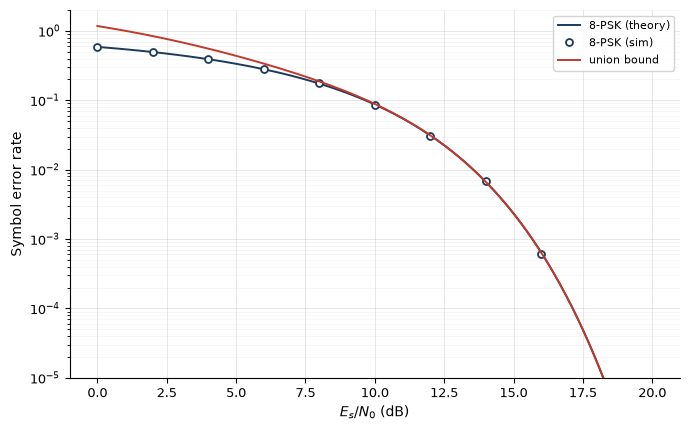

In [22]:
def union_bound_ser(c, esn0_db):
    n0 = 10 ** (-np.asarray(esn0_db) / 10)
    d = np.abs(c.points[:, None] - c.points[None, :])
    d = d[~np.eye(c.M, dtype=bool)]
    return np.array([np.sum(cl.qfunc(d / np.sqrt(2 * nn))) / c.M for nn in np.atleast_1d(n0)])

c8 = cl.get_constellation("8psk")
es = np.arange(0, 21, 2.0)
ser_sim = []
for e in es:
    s = c8.modulate(cl.random_bits(3 * 100_000, rng))
    ser_sim.append(np.mean(c8.decide(cl.awgn_esn0(s, e, rng=rng)[0]) != s))
esf = np.linspace(0, 20, 200)
f, ax = lk.fig("ber")
lk.ber_plot(ax, es, {"8-PSK": ser_sim}, {"8-PSK": cl.ser_mpsk(esf, 8), "union bound": union_bound_ser(c8, esf)},
            x_theory=esf, xlabel="$E_s/N_0$ (dB)", ylabel="Symbol error rate", ylim=(1e-5, 2))
lk.show(f)

**What you should see.** The union bound exceeds 1 at low SNR (useless there) and merges
with the exact curve below about $10^{-2}$.

## 7. Orthogonal FSK and DPSK: noncoherent detection

Coherent detection needs the carrier phase. When that is expensive (cheap IoT radios,
fast-fading channels, burst-mode links), two classic alternatives remain:

* **Noncoherent orthogonal FSK**: each symbol is one of $M$ orthogonal tones; the
  receiver compares the *energies* $|r_m|^2$ of the correlator outputs and never needs the
  phase. For binary FSK, $P_b = \tfrac12 e^{-E_b/2N_0}$ (coherent: $Q(\sqrt{E_b/N_0})$).
* **DPSK**: information sits in the phase *change* between symbols; the receiver
  computes $\mathrm{Re}\{r_k r_{k-1}^*\}$. Binary DPSK: $P_b = \tfrac12 e^{-E_b/N_0}$, within
  about 1 dB of coherent BPSK at $10^{-5}$.

We simulate at the symbol level: the FSK correlator outputs are an $M$-vector with the
transmitted entry equal to $\sqrt{E_s}e^{j\theta}$ (unknown phase $\theta$) and the rest pure noise.

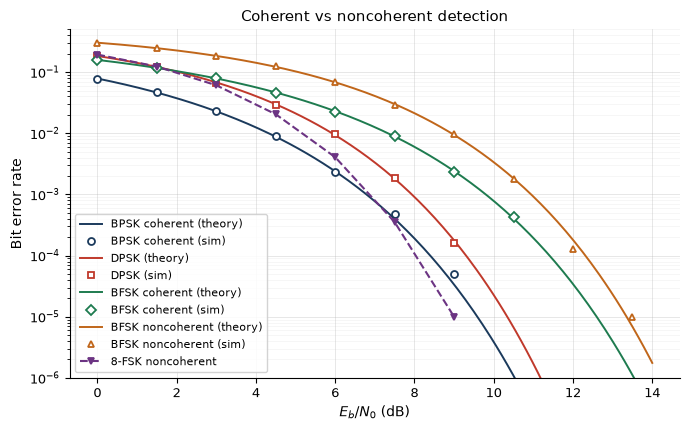

In [25]:
def fsk_ber(M, ebn0_db, coherent, n=100_000):
    k = int(np.log2(M))
    es = k * 10 ** (ebn0_db / 10)                             # N0 = 1
    sym = rng.integers(0, M, n)
    theta = rng.uniform(0, 2 * np.pi, n) if not coherent else np.zeros(n)
    R = (rng.standard_normal((n, M)) + 1j * rng.standard_normal((n, M))) / np.sqrt(2)
    R[np.arange(n), sym] += np.sqrt(es) * np.exp(1j * theta)
    det = np.argmax(R.real if coherent else np.abs(R), axis=1)
    bits_err = np.array([bin(v).count("1") for v in range(M)])[det ^ sym]   # natural labels
    return bits_err.sum() / (n * k)

def dpsk_ber(ebn0_db, n=200_000):
    b = cl.random_bits(n, rng)
    x = np.exp(1j * np.pi * np.cumsum(b))                    # differential encoding
    x = x * np.exp(1j * rng.uniform(0, 2 * np.pi))            # unknown but constant phase
    y, _ = cl.awgn_esn0(x, ebn0_db, rng=rng)
    d = np.real(y[1:] * np.conj(y[:-1])) < 0
    return np.mean(d != b[1:].astype(bool))

eb7 = np.arange(0, 15, 1.5)
ebf = np.linspace(0, 14, 200)
g = 10 ** (ebf / 10)
sims = {"BPSK coherent": [np.mean((cl.awgn_esn0(np.ones(200_000), e, rng=rng)[0].real < 0)) for e in eb7],
        "DPSK": [dpsk_ber(e) for e in eb7],
        "BFSK coherent": [fsk_ber(2, e, True) for e in eb7],
        "BFSK noncoherent": [fsk_ber(2, e, False) for e in eb7],
        "8-FSK noncoherent": [fsk_ber(8, e, False) for e in eb7]}
theory = {"BPSK coherent": cl.ber_bpsk(ebf), "DPSK": 0.5 * np.exp(-g),
          "BFSK coherent": cl.qfunc(np.sqrt(g)), "BFSK noncoherent": 0.5 * np.exp(-g / 2)}
f, ax = lk.fig("ber")
lk.ber_plot(ax, eb7, sims, theory, x_theory=ebf)
ax.set_title("Coherent vs noncoherent detection")
lk.show(f)

**What you should see.** Binary FSK is 3 dB behind BPSK (orthogonal instead of antipodal
signals) and noncoherent detection costs another ~1 dB at $10^{-5}$. DPSK sits just right of
BPSK. Larger $M$ helps FSK: 8-FSK needs *less* $E_b/N_0$ than BFSK, at the cost of
bandwidth. This is the power-efficient, bandwidth-hungry corner that LoRa (Chapter 22)
and deep-space links exploit.

### Try it yourself 7.1
Using the closed forms, how many dB more $E_b/N_0$ does noncoherent BFSK need than coherent
BPSK to reach $P_b = 10^{-5}$?

In [27]:
answer_7_1 = None
e_bpsk = brentq(lambda e: np.log10(cl.ber_bpsk(e)) + 5, 0, 20)
e_ncfsk = 10 * np.log10(-2 * np.log(2e-5))
lk.check("7.1 noncoherent BFSK penalty vs BPSK (dB)", answer_7_1, e_ncfsk - e_bpsk, atol=0.1)

[TODO] 7.1 noncoherent BFSK penalty vs BPSK (dB): not attempted yet: replace the None with your answer

## 8. Constant envelope: MSK and GMSK

**MSK** is binary FSK with the minimum tone spacing $1/(2T)$ *and* continuous phase: the
phase ramps by $\pm\pi/2$ per bit. The envelope is constant (PAPR 0 dB, perfect for a
saturated amplifier) and the spectrum falls as $f^{-4}$. **GMSK** first smooths the
frequency pulses with a Gaussian filter of bandwidth-time product $BT$ (0.3 in GSM, 0.5 in
Bluetooth LE), which compacts the spectrum further at the cost of a little ISI.

### Interactive: GMSK bandwidth-time product

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

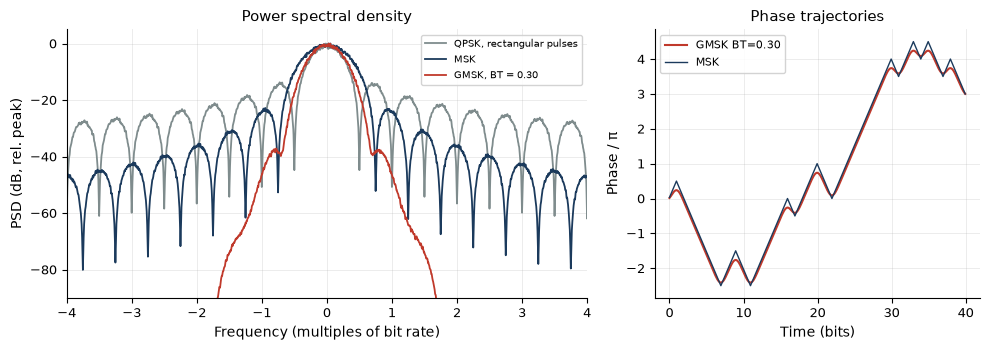

In [29]:
def cpm(bits, sps, h=0.5, bt=None):
    """Continuous-phase FSK/MSK/GMSK baseband waveform (unit amplitude)."""
    nrz = np.repeat(2.0 * bits - 1, sps)
    if bt is not None:                                        # Gaussian frequency-pulse filter
        tg = np.arange(-2 * sps, 2 * sps + 1) / sps
        sig = np.sqrt(np.log(2)) / (2 * np.pi * bt)
        gk = np.exp(-tg ** 2 / (2 * sig ** 2)); gk /= gk.sum()
        nrz = np.convolve(nrz, gk, mode="same")
    phase = np.pi * h * np.cumsum(nrz) / sps
    return np.exp(1j * phase)

def msk_family(bt=0.3):
    sps = 16
    bits = cl.random_bits(20_000, rng)
    xq = cl.shape(qpsk.modulate(bits), np.ones(2 * sps) / np.sqrt(2 * sps), 2 * sps)   # rect QPSK
    f, ax = lk.fig("row2", 1, 2, gridspec_kw={"width_ratios": [1.6, 1]})
    for x, lab, col in [(xq, "QPSK, rectangular pulses", lk.GRAY), (cpm(bits, sps), "MSK", lk.NAVY),
                        (cpm(bits, sps, bt=bt), f"GMSK, BT = {bt:.2f}", lk.RED)]:
        lk.psd(ax[0], x, sps, 4096, label=lab, color=col)
    ax[0].set_xlim(-4, 4); ax[0].set_ylim(-90, 5); ax[0].set_xlabel("Frequency (multiples of bit rate)")
    ax[0].legend(loc="upper right", fontsize=7.5); ax[0].set_title("Power spectral density")
    g = cpm(bits[:40], sps, bt=bt)
    ax[1].plot(np.arange(len(g)) / sps, np.unwrap(np.angle(g)) / np.pi, color=lk.RED, label=f"GMSK BT={bt:.2f}")
    ax[1].plot(np.arange(len(g)) / sps, np.unwrap(np.angle(cpm(bits[:40], sps))) / np.pi, color=lk.NAVY,
               lw=1, label="MSK")
    ax[1].set_xlabel("Time (bits)"); ax[1].set_ylabel("Phase / π"); ax[1].legend(fontsize=8)
    ax[1].set_title("Phase trajectories")
    lk.show(f)

lk.interact(msk_family, bt=lk.slider(0.3, 0.15, 1.0, 0.05, "GMSK BT"))

**What you should see.** MSK's main lobe is wider than QPSK's but its sidelobes fall much
faster; GMSK with BT = 0.3 is more than 40 dB down at about 1.5 times the bit rate from
the carrier. On the right, MSK phase is piecewise linear; GMSK rounds the corners.
Smaller BT = tighter spectrum, more ISI.

## 9. Soft information: bit LLRs

Modern decoders (LDPC, polar, turbo) consume log-likelihood ratios, not hard bits. For bit
$b_i$ of a symbol,

$$\mathrm{LLR}_i = \log\frac{\sum_{a:b_i=0} e^{-|y-a|^2/N_0}}{\sum_{a:b_i=1} e^{-|y-a|^2/N_0}},$$

and the max-log approximation keeps only the nearest point in each set. Below: the LLRs of
the two in-phase bits of 16-QAM along the I axis.

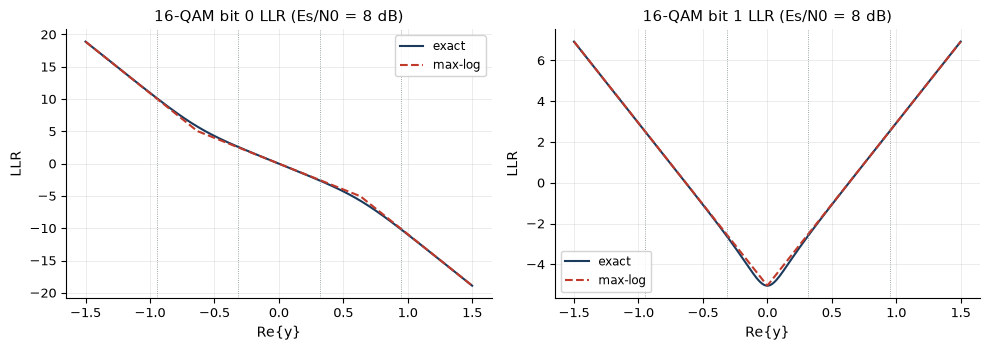

In [32]:
c = cl.get_constellation("16qam")
x = np.linspace(-1.5, 1.5, 400)
n0 = 10 ** (-8 / 10)
f, ax = lk.fig("row2", 1, 2)
for b in range(2):
    ex = c.llr(x + 0j, n0, exact=True).reshape(-1, 4)[:, b]
    ml = c.llr(x + 0j, n0, exact=False).reshape(-1, 4)[:, b]
    ax[b].plot(x, ex, label="exact"); ax[b].plot(x, ml, "--", label="max-log")
    for p in np.unique(c.points.real):
        ax[b].axvline(p, color=lk.GRAY, lw=0.6, ls=":")
    ax[b].set_title(f"16-QAM bit {b} LLR (Es/N0 = 8 dB)")
    ax[b].set_xlabel("Re{y}"); ax[b].set_ylabel("LLR"); ax[b].legend()
lk.show(f)

**What you should see.** Bit 0 (the sign bit) has an LLR that is roughly linear in $y$;
bit 1 (inner or outer pair of levels) is most negative at 0, because the inner points carry
a 1, and changes sign halfway between inner and outer points, at $\pm 2/\sqrt{10}$.
Max-log is almost indistinguishable from exact except near the boundaries, which is why
every hardware demapper uses it.

## Key takeaways
* In AWGN the optimal detector is minimum distance; decision regions are Voronoi cells.
* $d_{\min}$ and the number of nearest neighbours predict high-SNR performance
  ($P_s \approx N_{\min} Q(d_{\min}/\sqrt{2N_0})$); the union bound is tight there.
* Gray labelling makes BER ≈ SER/k for free.
* Noncoherent detection (FSK, DPSK) costs about 1 dB but removes the phase-recovery problem.
* Constant-envelope CPM (MSK, GMSK) trades bandwidth for amplifier efficiency.
* Decoders want LLRs; max-log demapping is nearly lossless.

## Going further (hardware: USRP B200 / GNU Radio)
* `gnuradio/gr02_psk_link.py --sim --snr 12` runs a live QPSK link; change the
  constellation object in the script to 8-PSK or 16-QAM and compare the measured BER with Section 4.
* GNU Radio's `GFSK Mod`/`GMSK Mod` blocks implement Section 8; loop a GMSK signal through the
  B200 (with an attenuator) and compare the measured spectrum with the interactive plot.

## Exercises
1. **(Warm-up)** Derive $d_{\min} = \sqrt{6/(M-1)}$ for unit-energy square $M$-QAM.
2. **(Core)** At what $E_b/N_0$ do 8-PSK and 16-QAM reach BER $10^{-5}$? Explain why 16-QAM
   wins even though it carries more bits per symbol.
3. **(Core)** Optimise the ring ratio of 16-APSK for SER at $E_s/N_0 = 12$ dB and compare its
   PAPR with 16-QAM. DVB-S2 (ETSI EN 302 307) specifies ratios between about 2.6 and 3.2
   depending on code rate.
4. **(Core)** Implement coherent MSK detection as offset-QPSK with half-sine pulses and show
   its BER equals BPSK's.
5. **(Stretch)** Build a noncoherent 8-FSK receiver at the waveform level (tone spacing
   $1/T$, correlator bank) and reproduce the symbol-level curve of Section 7.

In [35]:
lk.summary()

[good] Lab 02 finished in 5.0 s. Self-checks: 0 passed, 0 failed, 3 still to do.